# ABSA MBG — Analisis Sentimen Program Makan Bergizi Gratis
**Komparasi Multinomial Naïve Bayes vs LinearSVC**

Notebook ini mereplikasi pipeline yang sama persis dengan aplikasi Streamlit:
1. Instalasi & Import
2. Load Dataset (kolom `full_text`, 20.912 baris)
3. Preprocessing: Cleaning → Normalisasi → Segmentasi → Stopword → Stemming
4. Pelabelan RoBERTa + Penanganan Netral (hapus)
5. Identifikasi Aspek Rule-Based (termasuk 'Lainnya')
6. Training 3 Skenario Split: 70:30, 80:20, 90:10
7. Evaluasi Global + Per Aspek (semua aspek termasuk Lainnya)
8. Simpan Joblib (model 80:20 sebagai final)

---
## 1. Instalasi & Import

In [ ]:
!pip install PySastrawi transformers accelerate openpyxl wordcloud -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 7.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re, string, warnings, joblib, time, requests
from io import BytesIO

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import torch
from transformers import pipeline as hf_pipeline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)

device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU (CUDA)' if device == 0 else 'CPU'}")
print('Import selesai.')

Device: GPU (CUDA)
Import selesai.


---
## 2. Load Dataset

In [ ]:
from google.colab import files
print('Upload file CSV dataset:')
uploaded = files.upload()

Upload file CSV dataset:


Saving DataSkripsi - hasil_analisis_aspek_sentimen.csv to DataSkripsi - hasil_analisis_aspek_sentimen.csv


In [ ]:
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(filename, encoding='utf-8')
assert 'full_text' in df_raw.columns, "Kolom 'full_text' tidak ditemukan."
df_raw = df_raw[['full_text']].dropna().reset_index(drop=True)
df_raw['full_text'] = df_raw['full_text'].astype(str)
print(f'Dataset dimuat: {len(df_raw)} baris')
df_raw.head()

Dataset dimuat: 20912 baris


,full_text
0,Dukung Program Makan Bergizi Gratis. mantap\n#...
1,Dukung bersama Program Makan Bergizi Gratis. M...
2,Dukung bersama Program Makan Bergizi Gratis. \...
3,Dukung Program Makan Bergizi Gratis. #FaktaInd...
4,@DanangAMahendra Masih nunggu makan bergizi gr...


---
## 3. Preprocessing

Pipeline identik dengan Streamlit: Cleaning → Normalisasi → Segmentasi → Stopword Removal → Stemming Sastrawi

In [ ]:
# ── Inisialisasi (identik dengan load_resources() di Streamlit) ──
factory_stem = StemmerFactory()
stemmer = factory_stem.create_stemmer()

factory_stop = StopWordRemoverFactory()
sw_sastrawi = set(factory_stop.get_stop_words())
sw_custom = {
    'yg','dg','rt','dgn','ny','d','klo','kalo','amp',
    'biar','bikin','udah','udh','aja','sih','deh','nih',
    'lah','dong','kan','tuh','mah','wkwk','haha','hehe',
    'aku','saya','kamu','dia','kita','kami','mereka','sama'
}
negation_words = {'tidak','tak','tiada','bukan','jangan','belum','kurang','gak','ga','nggak','enggak'}
final_stopwords = (sw_sastrawi | sw_custom) - negation_words

# Konjungsi identik dengan Streamlit
KONJUNGSI     = r'\b(tetapi|namun|meskipun|tapi|sedangkan|cuman|cuma|sayangnya|padahal|walau|walaupun|pasalnya)\b'
KONJUNGSI_SET = {'tetapi','namun','meskipun','tapi','sedangkan','cuman','cuma','sayangnya','padahal','walau','walaupun','pasalnya'}

# Kamus normalisasi
KAMUS_URL = 'https://github.com/analysisdatasentiment/kamus_kata_baku/raw/main/kamuskatabaku.xlsx'
try:
    resp = requests.get(KAMUS_URL, timeout=15)
    xls  = pd.read_excel(BytesIO(resp.content), engine='openpyxl')
    cols = xls.columns.tolist()
    norm_dict = dict(zip(xls[cols[0]].astype(str).str.lower(), xls[cols[1]].astype(str).str.lower()))
    print(f'Kamus normalisasi: {len(norm_dict)} entri')
except Exception as e:
    norm_dict = {'yg':'yang','gk':'tidak','ga':'tidak','gak':'tidak','bgt':'banget'}
    print(f'Fallback kamus: {e}')

print('Resources siap.')

Kamus normalisasi: 4347 entri
Resources siap.


In [ ]:
# ── Fungsi preprocessing (identik dengan Streamlit) ──
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return re.sub(r'\s+', ' ', text).strip()

def normalize_text(text):
    return ' '.join(norm_dict.get(w, w) for w in text.split())

def segmentasi_kalimat(text):
    parts = re.split(KONJUNGSI, text)
    return [s.strip() for s in parts if s.strip() and s.strip() not in KONJUNGSI_SET] or [text]

def stopword_and_stem(text):
    words = [w for w in text.split() if w not in final_stopwords]
    return stemmer.stem(' '.join(words))

print('Fungsi preprocessing terdefinisi.')

# Contoh trace
contoh = 'makanan bergizi gratis ini enak banget tapi distribusinya sering telat ke sekolah!'
c1 = clean_text(contoh)
c2 = normalize_text(c1)
c3 = segmentasi_kalimat(c2)
c4 = [stopword_and_stem(s) for s in c3]
print(f'Asli    : {contoh}')
print(f'Cleaned : {c1}')
print(f'Normed  : {c2}')
print(f'Segmen  : {c3}')
print(f'Final   : {c4}')

Fungsi preprocessing terdefinisi.
Asli    : makanan bergizi gratis ini enak banget tapi distribusinya sering telat ke sekolah!
Cleaned : makanan bergizi gratis ini enak banget tapi distribusinya sering telat ke sekolah
Normed  : makanan bergizi gratis ini enak banget tapi distribusinya sering telat ke sekolah
Segmen  : ['makanan bergizi gratis ini enak banget', 'distribusinya sering telat ke sekolah']
Final   : ['makan gizi gratis banget', 'distribusi telat sekolah']


In [ ]:
# ── Jalankan preprocessing pada seluruh data ──
# Identik dengan Tab 2 Streamlit: hapus duplikat → cleaning → normalisasi
# → segmentasi → explode → stopword → stemming
print('Menjalankan preprocessing...')
t0 = time.time()

# Tahap 0: Hapus duplikat (anti-buzzer)
df = df_raw.drop_duplicates(subset=['full_text']).copy().reset_index(drop=True)
df['doc_id'] = range(len(df))
count_awal = len(df)
print(f'  Setelah hapus duplikat: {count_awal} baris (dihapus {len(df_raw)-count_awal})')

# Tahap 1-2: Cleaning & Normalisasi
df['text_clean'] = df['full_text'].apply(clean_text)
df['text_norm']  = df['text_clean'].apply(normalize_text)
count_norm = len(df)

# Tahap 3: Segmentasi + Explode
df['segmen_list'] = df['text_norm'].apply(segmentasi_kalimat)
df_exp = df.explode('segmen_list').dropna(subset=['segmen_list'])
df_exp['segment'] = df_exp['segmen_list'].astype(str).str.strip()
df_exp = df_exp[df_exp['segment'] != ''].copy()
count_segmentasi = len(df_exp)
print(f'  Setelah segmentasi: {count_segmentasi} segmen')

# Tahap 4-5: Stopword + Stemming (dengan progress)
processed = []
total = len(df_exp)
for i, seg in enumerate(df_exp['segment']):
    no_stop = ' '.join([w for w in seg.split() if w not in final_stopwords])
    stemmed = stemmer.stem(no_stop) if no_stop.strip() else ''
    processed.append(stemmed)
    if i % max(1, total // 20) == 0:
        print(f'  Stemming: {i}/{total}', end='\r')

df_exp['segment'] = processed
df_exp = df_exp[df_exp['segment'].str.strip() != ''].reset_index(drop=True)
count_final = len(df_exp)

elapsed = time.time() - t0
print(f'\nPreprocessing selesai: {elapsed:.1f} detik')
print(f'\nStatistik:')
print(f'  Data mentah awal          : {len(df_raw)}')
print(f'  Setelah hapus duplikat    : {count_awal}')
print(f'  Setelah segmentasi        : {count_segmentasi}')
print(f'  Final (setelah stem+stop) : {count_final}')
df_exp[['doc_id', 'full_text', 'segment']].head(5)

Menjalankan preprocessing...
  Setelah hapus duplikat: 20594 baris (dihapus 318)
  Setelah segmentasi: 23284 segmen
  Stemming: 23280/23284
Preprocessing selesai: 3.1 detik

Statistik:
  Data mentah awal          : 20912
  Setelah hapus duplikat    : 20594
  Setelah segmentasi        : 23284
  Final (setelah stem+stop) : 23256


,doc_id,full_text,segment
0,0,Dukung Program Makan Bergizi Gratis. mantap\n#...,dukung program makan gizi gratis mantap
1,1,Dukung bersama Program Makan Bergizi Gratis. M...,dukung program makan gizi gratis membuaat anak...
2,2,Dukung bersama Program Makan Bergizi Gratis. \...,dukung program makan gizi gratis
3,3,Dukung Program Makan Bergizi Gratis. #FaktaInd...,dukung program makan gizi gratis
4,4,@DanangAMahendra Masih nunggu makan bergizi gr...,tunggu makan gizi gratis


---
## 4. Pelabelan RoBERTa + Penanganan Netral

Identik dengan Tab 3 Streamlit: RoBERTa → deteksi Netral → **hapus** data Netral (bukan diubah ke Positif)

In [ ]:
print('Loading model RoBERTa...')
MODEL_NAME = 'w11wo/indonesian-roberta-base-sentiment-classifier'
classifier = hf_pipeline(
    'text-classification',
    model=MODEL_NAME,
    device=device,
    truncation=True,
    max_length=128
)
print(f"Model siap. Device: {'GPU' if device == 0 else 'CPU'}")

Loading model RoBERTa...


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Model siap. Device: GPU


In [ ]:
def determine_sentiment_roberta(text):
    if not isinstance(text, str) or not text.strip():
        return 'Netral'
    try:
        result = classifier(text[:512])[0]
        label  = result['label'].lower()
        if 'pos' in label: return 'Positif'
        if 'neg' in label: return 'Negatif'
        return 'Netral'
    except Exception:
        return 'Netral'

# Pelabelan dengan batch (lebih cepat di GPU)
def batch_predict(texts, batch_size=64):
    results = []
    total   = len(texts)
    for i in range(0, total, batch_size):
        batch  = texts[i:i+batch_size]
        preds  = classifier(batch)
        for p in preds:
            lbl = p['label'].lower()
            if 'pos' in lbl: results.append('Positif')
            elif 'neg' in lbl: results.append('Negatif')
            else: results.append('Netral')
        if (i // batch_size) % 10 == 0:
            print(f'  Progress: {min(i+batch_size, total)}/{total}', end='\r')
    return results

print('Menjalankan pelabelan RoBERTa...')
t0 = time.time()

# RoBERTa dijalankan pada segment (setelah preprocessing) — sama dengan Streamlit
df_exp['sentiment_label'] = batch_predict(df_exp['segment'].tolist())

elapsed = time.time() - t0
print(f'\nPelabelan selesai: {elapsed/60:.1f} menit')

# Distribusi sebelum penanganan Netral
print('\nDistribusi SEBELUM penanganan Netral:')
print(df_exp['sentiment_label'].value_counts())

Menjalankan pelabelan RoBERTa...

Pelabelan selesai: 1.1 menit

Distribusi SEBELUM penanganan Netral:
sentiment_label
Positif    3003
Negatif    2084
Name: count, dtype: int64


In [ ]:
# ── Penanganan Netral: HAPUS (identik pilihan default Streamlit) ──
df_neutral = df_exp[df_exp['sentiment_label'] == 'Netral'].copy()
print(f'Segmen Netral dihapus: {len(df_neutral)}')

df_exp = df_exp[df_exp['sentiment_label'] != 'Netral'].reset_index(drop=True)
print(f'Sisa segmen setelah hapus Netral: {len(df_exp)}')

dist = df_exp['sentiment_label'].value_counts()
pct  = df_exp['sentiment_label'].value_counts(normalize=True).mul(100).round(1)
print('\nDistribusi SETELAH penanganan Netral:')
for lbl in dist.index:
    print(f'  {lbl}: {dist[lbl]} ({pct[lbl]}%)')

Segmen Netral dihapus: 18169
Sisa segmen setelah hapus Netral: 5087

Distribusi SETELAH penanganan Netral:
  Positif: 3003 (59.0%)
  Negatif: 2084 (41.0%)


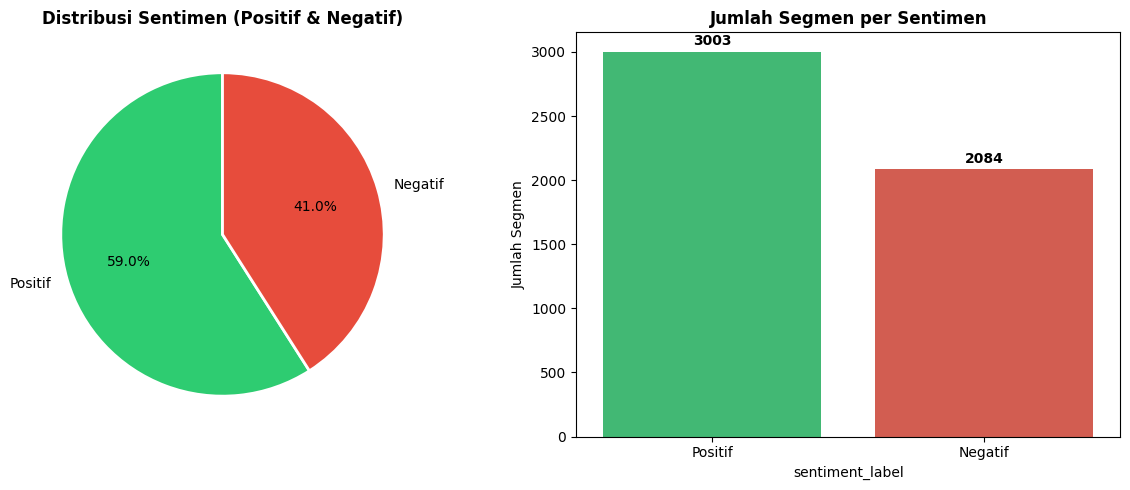

In [ ]:
# ── Visualisasi distribusi sentimen (tanpa Netral) ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {'Positif': '#2ecc71', 'Negatif': '#e74c3c'}
vals   = df_exp['sentiment_label'].value_counts()
cols   = [colors[l] for l in vals.index]

# Pie chart
axes[0].pie(vals.values, labels=vals.index, autopct='%1.1f%%',
            colors=cols, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Distribusi Sentimen (Positif & Negatif)', fontweight='bold')

# Bar chart
sns.barplot(x=vals.index, y=vals.values, palette=cols, ax=axes[1], hue=vals.index, legend=False)
axes[1].set_title('Jumlah Segmen per Sentimen', fontweight='bold')
axes[1].set_ylabel('Jumlah Segmen')
for i, v in enumerate(vals.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Identifikasi Aspek Rule-Based

Identik dengan Streamlit — semua aspek ditampilkan termasuk 'Lainnya'

In [ ]:
ASPEK_DICT = {
    'Kualitas': [
        'kualitas','bagus','jelek','enak','basi','gizi','susu',
        'menu','rasa','porsi','higienis','keracunan','sehat',
        'mentah','keras','hambar','ulat','lauk','sayur',
        'karbohidrat','protein','lemak','gula','ayam','telur',
        'kenyang','alergi','higienitas'
    ],
    'Layanan': [
        'layan','antri','ramah','lambat','cepat','bantu','saji',
        'distribusi','vendor','katering','sekolah','siswa','guru',
        'telat','molor','bocor','tepat waktu','pelosok','merata',
        'zonasi','umkm','kemasan','kotak','plastik'
    ],
    'Anggaran': [
        'harga','mahal','murah','biaya','bayar','anggar','boros',
        'korupsi','dana','apbn','pajak','potong','sunat','markup',
        'tender','proyek','apbd','defisit','utang','ekonomi',
        'alokasi','transparan'
    ],
}

def get_aspects(text):
    tokens = set(str(text).split())
    found  = [asp for asp, keys in ASPEK_DICT.items() if not tokens.isdisjoint(keys)]
    return found if found else ['Lainnya']

df_exp['aspect_list'] = df_exp['segment'].apply(get_aspects)

# Statistik semua aspek termasuk Lainnya
df_asp = df_exp.explode('aspect_list')
asp_counts = df_asp['aspect_list'].value_counts()
print('Distribusi Aspek (termasuk Lainnya):')
print(asp_counts.to_string())

Distribusi Aspek (termasuk Lainnya):
aspect_list
Kualitas    4344
Layanan      870
Lainnya      621
Anggaran     365


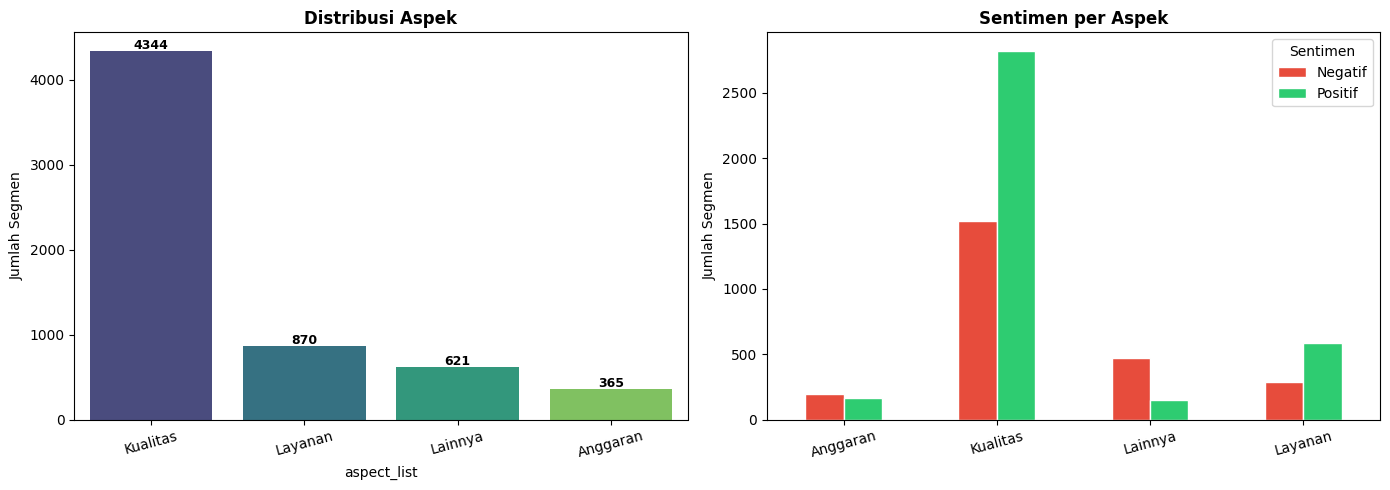

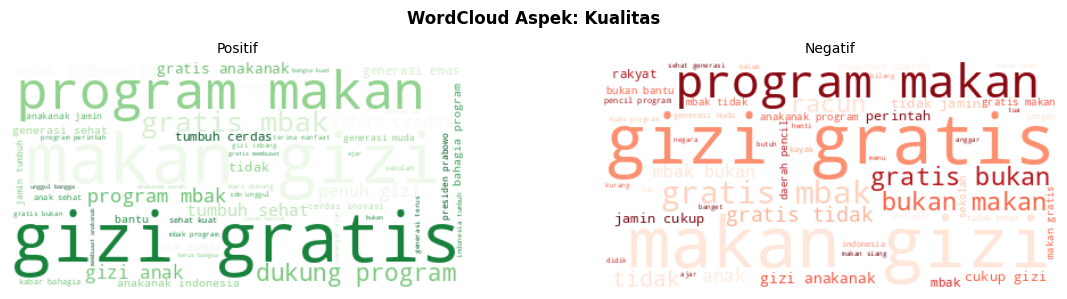

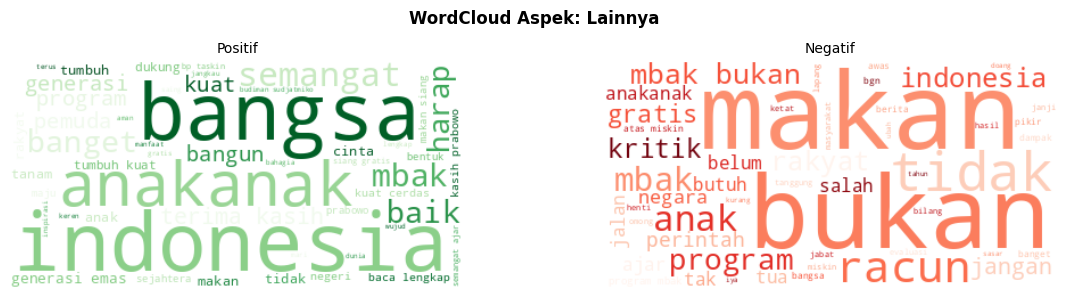

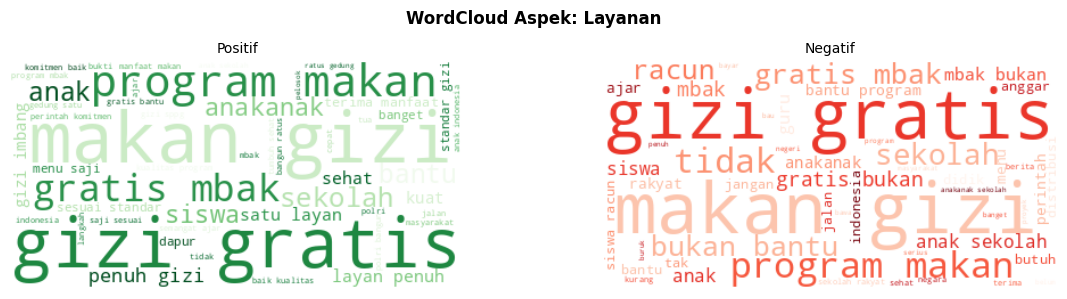

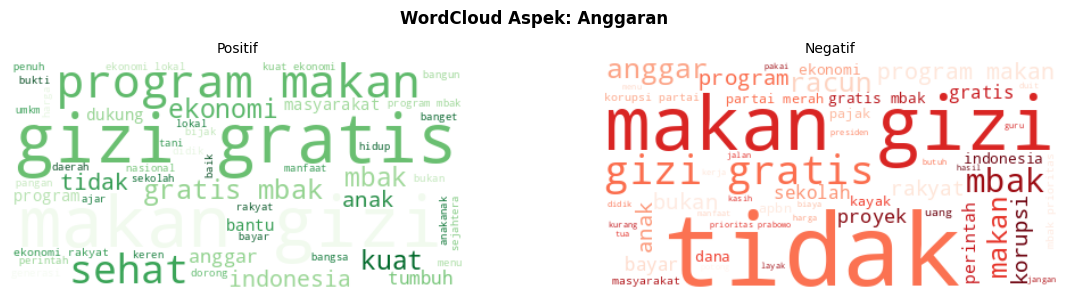

In [ ]:
# ── Visualisasi aspek (semua aspek termasuk Lainnya) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart semua aspek
sns.barplot(x=asp_counts.index, y=asp_counts.values,
            palette='viridis', ax=axes[0], hue=asp_counts.index, legend=False)
axes[0].set_title('Distribusi Aspek', fontweight='bold')
axes[0].set_ylabel('Jumlah Segmen')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(asp_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=9)

# Sentimen per aspek (semua aspek)
pivot = df_asp.groupby(['aspect_list', 'sentiment_label']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[1],
           color={'Positif': '#2ecc71', 'Negatif': '#e74c3c'},
           edgecolor='white')
axes[1].set_title('Sentimen per Aspek', fontweight='bold')
axes[1].set_ylabel('Jumlah Segmen')
axes[1].set_xlabel('')
axes[1].legend(title='Sentimen')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('distribusi_aspek.png', dpi=150, bbox_inches='tight')
plt.show()

# WordCloud per aspek (semua aspek termasuk Lainnya)
all_aspects = df_asp['aspect_list'].unique()
for asp in all_aspects:
    sub_asp = df_asp[df_asp['aspect_list'] == asp]
    fig_wc, ax_wc = plt.subplots(1, 2, figsize=(12, 3))
    fig_wc.suptitle(f'WordCloud Aspek: {asp}', fontweight='bold')
    for ax, lbl, cmap in [(ax_wc[0],'Positif','Greens'), (ax_wc[1],'Negatif','Reds')]:
        teks = ' '.join(sub_asp[sub_asp['sentiment_label'] == lbl]['segment'].astype(str))
        if teks.strip():
            wc = WordCloud(width=400, height=200, background_color='white',
                           colormap=cmap, max_words=50).generate(teks)
            ax.imshow(wc, interpolation='bilinear')
        else:
            ax.text(0.5, 0.5, f'Tidak ada data {lbl}',
                    ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        ax.set_title(lbl, fontsize=10)
    plt.tight_layout()
    plt.savefig(f'wordcloud_{asp}.png', dpi=120, bbox_inches='tight')
    plt.show()

---
## 6. TF-IDF + Training 3 Skenario Split

Identik dengan Tab 4 Streamlit: 70:30, 80:20, 90:10 — model final adalah 80:20

In [ ]:
# Konfigurasi TF-IDF identik dengan Streamlit
TFIDF_PARAMS = {
    'max_features': 3000,
    'ngram_range'  : (1, 2),
    'sublinear_tf' : True,
    'min_df'       : 2,
    'max_df'       : 0.85
}

X = df_exp['segment']
y = df_exp['sentiment_label']

skenario_splits = {'70:30': 0.3, '80:20': 0.2, '90:10': 0.1}
hasil_skenario  = {}

for name, test_size in skenario_splits.items():
    print(f'\n=== Skenario {name} ===')

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    print(f'  Train: {len(X_train)} | Test: {len(X_test)}')

    # TF-IDF fit hanya pada training (mencegah data leakage)
    tfidf       = TfidfVectorizer(**TFIDF_PARAMS)
    X_train_vec = tfidf.fit_transform(X_train)
    X_test_vec  = tfidf.transform(X_test)

    # Multinomial NB (identik dengan Streamlit: MultinomialNB() tanpa parameter)
    t0    = time.perf_counter()
    nb    = MultinomialNB()
    nb.fit(X_train_vec, y_train)
    t_nb  = time.perf_counter() - t0
    y_pred_nb = nb.predict(X_test_vec)
    print(f'  NB  accuracy: {accuracy_score(y_test, y_pred_nb):.4f} | waktu: {t_nb:.4f}s')

    # LinearSVC (identik dengan Streamlit: LinearSVC() tanpa parameter)
    t0    = time.perf_counter()
    svm   = LinearSVC()
    svm.fit(X_train_vec, y_train)
    t_svm = time.perf_counter() - t0
    y_pred_svm = svm.predict(X_test_vec)
    print(f'  SVM accuracy: {accuracy_score(y_test, y_pred_svm):.4f} | waktu: {t_svm:.4f}s')

    # Simpan hasil
    test_df             = df_exp.loc[X_test.index].copy()
    test_df['y_true']   = y_test.values
    test_df['pred_nb']  = y_pred_nb
    test_df['pred_svm'] = y_pred_svm

    hasil_skenario[name] = {
        'model_nb': nb, 'model_svm': svm, 'vectorizer': tfidf,
        'y_test': y_test, 'y_pred_nb': y_pred_nb, 'y_pred_svm': y_pred_svm,
        't_nb': t_nb, 't_svm': t_svm, 'test_data_eval': test_df
    }

print('\nTraining ketiga skenario selesai.')


=== Skenario 70:30 ===
  Train: 3560 | Test: 1527
  NB  accuracy: 0.8690 | waktu: 0.0070s
  SVM accuracy: 0.9103 | waktu: 0.0367s

=== Skenario 80:20 ===
  Train: 4069 | Test: 1018
  NB  accuracy: 0.8664 | waktu: 0.0077s
  SVM accuracy: 0.9204 | waktu: 0.0380s

=== Skenario 90:10 ===
  Train: 4578 | Test: 509
  NB  accuracy: 0.8507 | waktu: 0.0084s
  SVM accuracy: 0.9057 | waktu: 0.0412s

Training ketiga skenario selesai.


---
## 7. Evaluasi Global + Per Aspek (Semua Skenario)


SKENARIO 70:30
               Accuracy  Precision    Recall  F1-Score  Train Time (s)
Model                                                                 
MultinomialNB  0.869024   0.869091  0.869024  0.869056          0.0070
LinearSVC      0.910282   0.910116  0.910282  0.910108          0.0367

Classification Report — MultinomialNB (70:30):
              precision    recall  f1-score   support

     Negatif       0.84      0.84      0.84       626
     Positif       0.89      0.89      0.89       901

    accuracy                           0.87      1527
   macro avg       0.86      0.86      0.86      1527
weighted avg       0.87      0.87      0.87      1527

Classification Report — LinearSVC (70:30):
              precision    recall  f1-score   support

     Negatif       0.90      0.88      0.89       626
     Positif       0.92      0.93      0.92       901

    accuracy                           0.91      1527
   macro avg       0.91      0.91      0.91      1527
weighted a

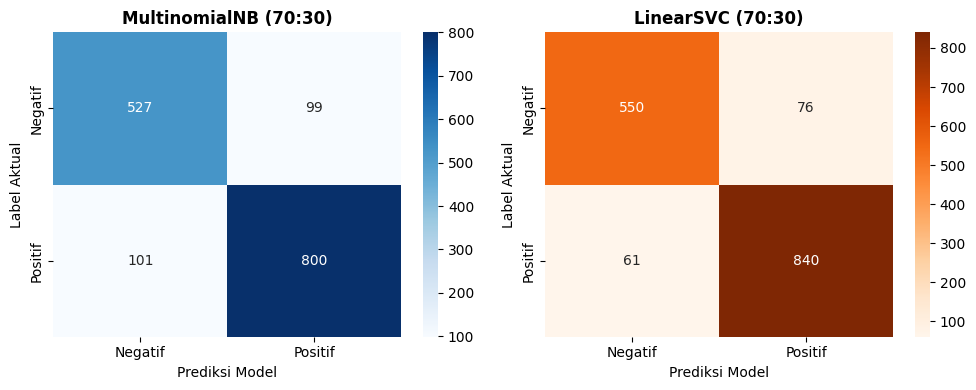


SKENARIO 80:20
               Accuracy  Precision    Recall  F1-Score  Train Time (s)
Model                                                                 
MultinomialNB  0.866405   0.867551  0.866405  0.866761          0.0077
LinearSVC      0.920432   0.920313  0.920432  0.920261          0.0380

Classification Report — MultinomialNB (80:20):
              precision    recall  f1-score   support

     Negatif       0.82      0.86      0.84       417
     Positif       0.90      0.87      0.89       601

    accuracy                           0.87      1018
   macro avg       0.86      0.86      0.86      1018
weighted avg       0.87      0.87      0.87      1018

Classification Report — LinearSVC (80:20):
              precision    recall  f1-score   support

     Negatif       0.91      0.89      0.90       417
     Positif       0.92      0.94      0.93       601

    accuracy                           0.92      1018
   macro avg       0.92      0.92      0.92      1018
weighted a

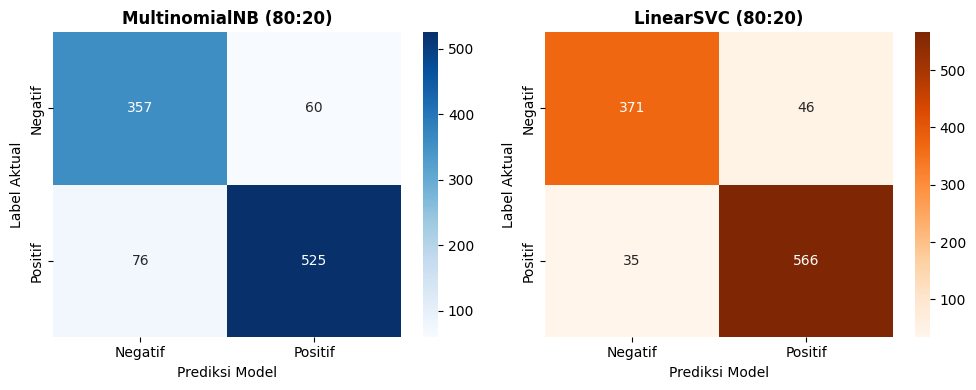


SKENARIO 90:10
               Accuracy  Precision    Recall  F1-Score  Train Time (s)
Model                                                                 
MultinomialNB  0.850688   0.850926  0.850688  0.850793          0.0084
LinearSVC      0.905697   0.905526  0.905697  0.905554          0.0412

Classification Report — MultinomialNB (90:10):
              precision    recall  f1-score   support

     Negatif       0.82      0.82      0.82       209
     Positif       0.88      0.87      0.87       300

    accuracy                           0.85       509
   macro avg       0.85      0.85      0.85       509
weighted avg       0.85      0.85      0.85       509

Classification Report — LinearSVC (90:10):
              precision    recall  f1-score   support

     Negatif       0.89      0.88      0.88       209
     Positif       0.91      0.93      0.92       300

    accuracy                           0.91       509
   macro avg       0.90      0.90      0.90       509
weighted a

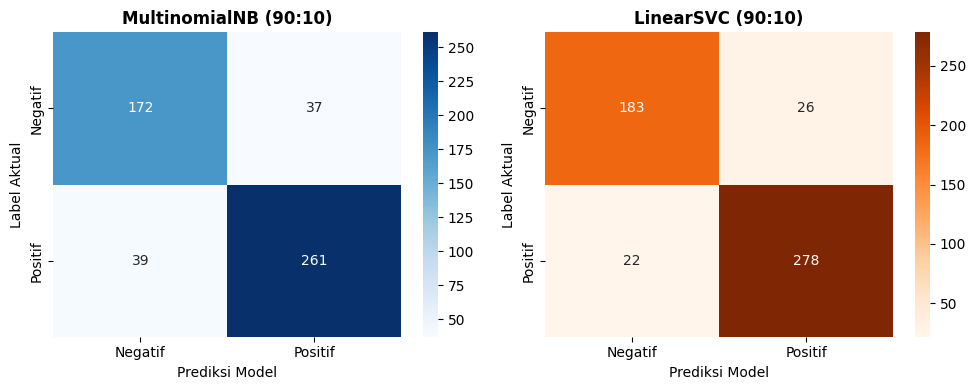

In [ ]:
def get_metrics(y_true, y_pred, name, t_train):
    return {
        'Model'          : name,
        'Accuracy'       : accuracy_score(y_true, y_pred),
        'Precision'      : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall'         : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score'       : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Train Time (s)' : round(t_train, 4),
    }

# ── Evaluasi semua skenario ──
for split_name, data in hasil_skenario.items():
    y_t   = data['y_test']
    p_nb  = data['y_pred_nb']
    p_svm = data['y_pred_svm']

    m_nb  = get_metrics(y_t, p_nb,  'MultinomialNB', data['t_nb'])
    m_svm = get_metrics(y_t, p_svm, 'LinearSVC',     data['t_svm'])

    print(f'\n{"="*55}')
    print(f'SKENARIO {split_name}')
    print(f'{"="*55}')
    df_met = pd.DataFrame([m_nb, m_svm]).set_index('Model')
    print(df_met.to_string())

    # Classification Report
    print(f'\nClassification Report — MultinomialNB ({split_name}):')
    print(classification_report(y_t, p_nb, zero_division=0))
    print(f'Classification Report — LinearSVC ({split_name}):')
    print(classification_report(y_t, p_svm, zero_division=0))

    # Confusion Matrix
    labels_cm = sorted(pd.concat([pd.Series(y_t), pd.Series(p_nb), pd.Series(p_svm)]).unique())
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, y_pred, title, cmap in [
        (axes[0], p_nb,  f'MultinomialNB ({split_name})', 'Blues'),
        (axes[1], p_svm, f'LinearSVC ({split_name})',     'Oranges'),
    ]:
        sns.heatmap(confusion_matrix(y_t, y_pred, labels=labels_cm),
                    annot=True, fmt='d', cmap=cmap,
                    xticklabels=labels_cm, yticklabels=labels_cm, ax=ax)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Prediksi Model')
        ax.set_ylabel('Label Aktual')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{split_name.replace(":","-")}.png', dpi=150, bbox_inches='tight')
    plt.show()

Ringkasan semua skenario:
Skenario         Model  Accuracy  F1-Score  Train Time (s)
   70:30 MultinomialNB  0.869024  0.869056          0.0070
   70:30     LinearSVC  0.910282  0.910108          0.0367
   80:20 MultinomialNB  0.866405  0.866761          0.0077
   80:20     LinearSVC  0.920432  0.920261          0.0380
   90:10 MultinomialNB  0.850688  0.850793          0.0084
   90:10     LinearSVC  0.905697  0.905554          0.0412


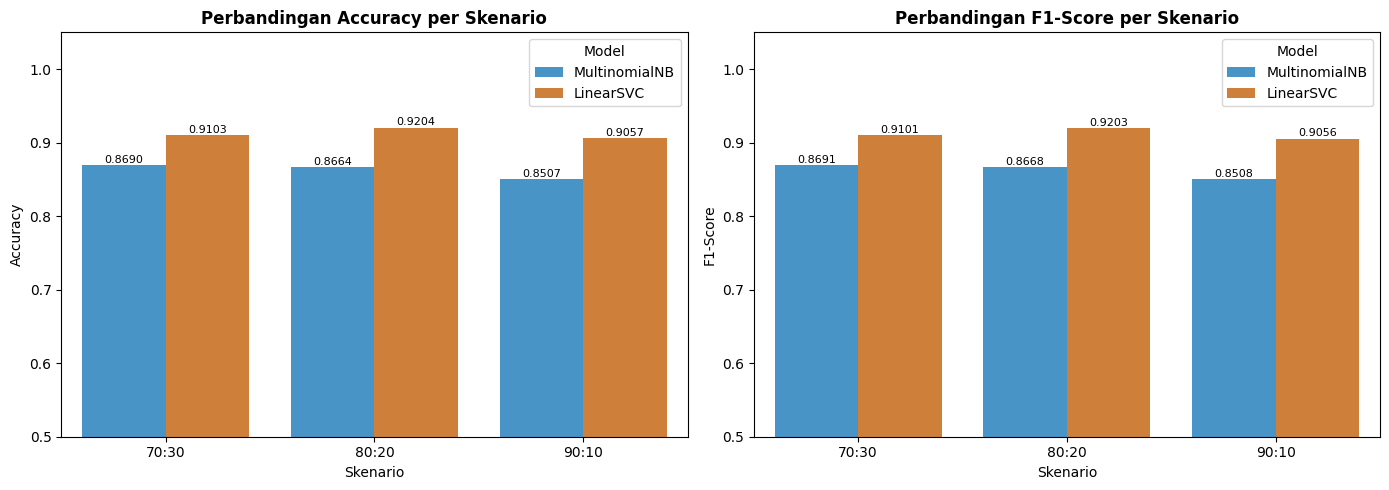

In [ ]:
# ── Visualisasi perbandingan antar skenario ──
summary_rows = []
for split_name, data in hasil_skenario.items():
    y_t = data['y_test']
    for model_name, y_pred, t_train in [
        ('MultinomialNB', data['y_pred_nb'],  data['t_nb']),
        ('LinearSVC',     data['y_pred_svm'], data['t_svm']),
    ]:
        summary_rows.append({
            'Skenario': split_name, 'Model': model_name,
            'Accuracy': accuracy_score(y_t, y_pred),
            'F1-Score': f1_score(y_t, y_pred, average='weighted', zero_division=0),
            'Train Time (s)': round(t_train, 4),
        })

df_summary = pd.DataFrame(summary_rows)
print('Ringkasan semua skenario:')
print(df_summary.to_string(index=False))

# Bar chart perbandingan akurasi antar skenario
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in [(axes[0], 'Accuracy'), (axes[1], 'F1-Score')]:
    sns.barplot(data=df_summary, x='Skenario', y=metric, hue='Model',
                palette=['#3498db','#e67e22'], ax=ax)
    ax.set_ylim(0.5, 1.05)
    ax.set_title(f'Perbandingan {metric} per Skenario', fontweight='bold')
    ax.set_ylabel(metric)
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.4f}',
                        (p.get_x() + p.get_width()/2, p.get_height() + 0.003),
                        ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('perbandingan_skenario.png', dpi=150, bbox_inches='tight')
plt.show()


EVALUASI PER ASPEK — Skenario 70:30
   Aspek  Jumlah Data Uji  Akurasi NB    F1 NB  Akurasi SVM   F1 SVM
Kualitas             1306    0.888974 0.889665     0.911945 0.911450
 Layanan              240    0.887500 0.889588     0.912500 0.912671
 Lainnya              186    0.752688 0.771606     0.913978 0.912231
Anggaran               98    0.836735 0.835506     0.897959 0.898044


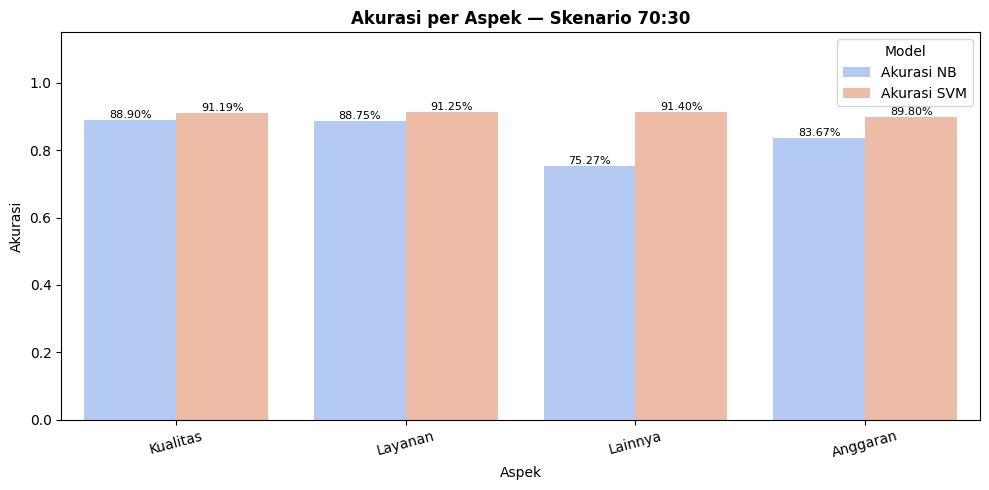


EVALUASI PER ASPEK — Skenario 80:20
   Aspek  Jumlah Data Uji  Akurasi NB    F1 NB  Akurasi SVM   F1 SVM
Kualitas              866    0.885681 0.887021     0.923788 0.923473
 Layanan              169    0.863905 0.866850     0.917160 0.917621
 Lainnya              127    0.763780 0.785818     0.929134 0.929684
Anggaran               68    0.823529 0.823529     0.867647 0.867909


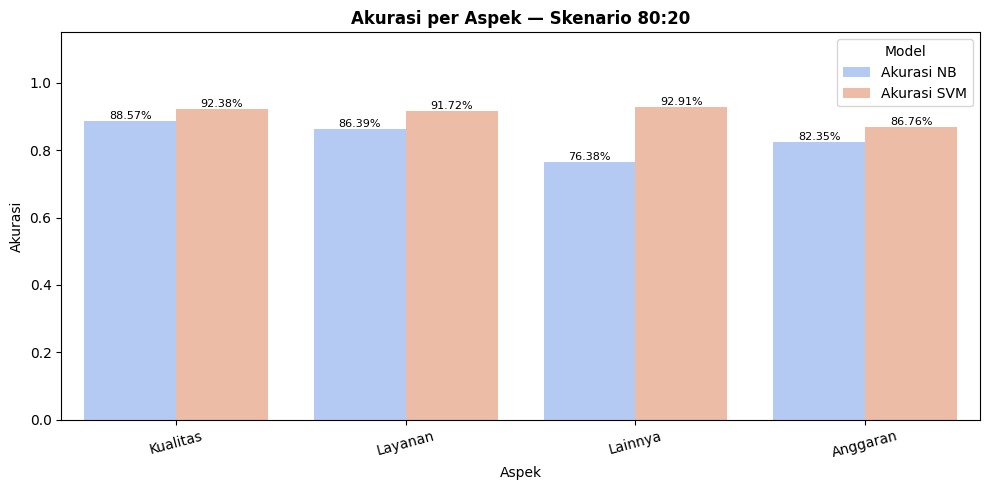


EVALUASI PER ASPEK — Skenario 90:10
   Aspek  Jumlah Data Uji  Akurasi NB    F1 NB  Akurasi SVM   F1 SVM
Kualitas              417    0.872902 0.874451     0.911271 0.910839
 Layanan               88    0.806818 0.812023     0.875000 0.877626
 Lainnya               73    0.767123 0.794147     0.917808 0.917808
Anggaran               32    0.812500 0.812500     0.875000 0.875000


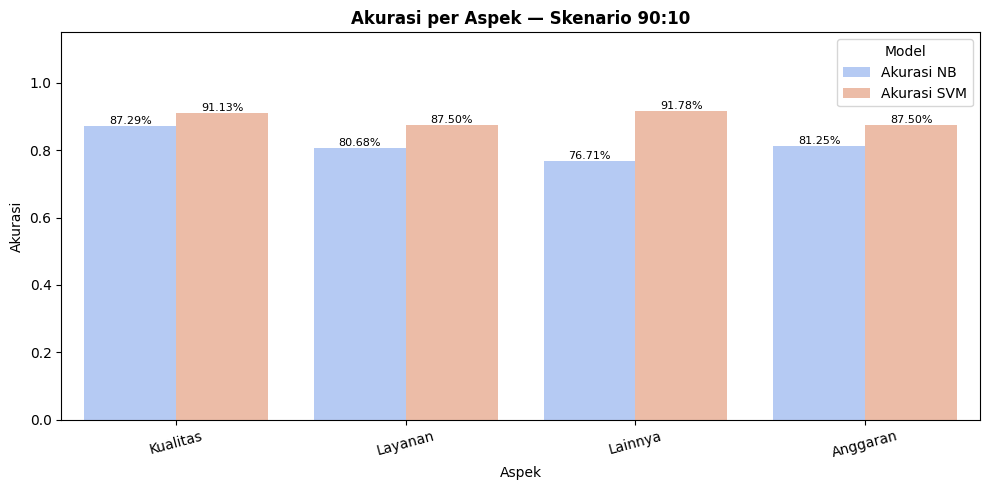

In [ ]:
# ── Evaluasi per aspek — semua aspek termasuk Lainnya ──
# Default tampilkan skenario 80:20 (identik Tab 5 Streamlit default)
for split_name in hasil_skenario.keys():
    data    = hasil_skenario[split_name]
    df_eval = data['test_data_eval'].copy()
    df_eval_exp = df_eval.explode('aspect_list')

    aspect_metrics = []
    for asp in df_eval_exp['aspect_list'].dropna().unique():
        sub = df_eval_exp[df_eval_exp['aspect_list'] == asp]
        if len(sub) == 0: continue
        aspect_metrics.append({
            'Aspek'        : asp,
            'Jumlah Data Uji': len(sub),
            'Akurasi NB'   : accuracy_score(sub['y_true'], sub['pred_nb']),
            'F1 NB'        : f1_score(sub['y_true'], sub['pred_nb'], average='weighted', zero_division=0),
            'Akurasi SVM'  : accuracy_score(sub['y_true'], sub['pred_svm']),
            'F1 SVM'       : f1_score(sub['y_true'], sub['pred_svm'], average='weighted', zero_division=0),
        })

    df_asp_met = pd.DataFrame(aspect_metrics).sort_values('Jumlah Data Uji', ascending=False)
    print(f'\n{"="*55}')
    print(f'EVALUASI PER ASPEK — Skenario {split_name}')
    print(f'{"="*55}')
    print(df_asp_met.to_string(index=False))

    # Visualisasi per aspek
    fig, ax = plt.subplots(figsize=(10, 5))
    df_asp_met.melt(
        id_vars='Aspek', value_vars=['Akurasi NB', 'Akurasi SVM'],
        var_name='Model', value_name='Akurasi'
    ).pipe(lambda d: sns.barplot(
        data=d, x='Aspek', y='Akurasi', hue='Model',
        palette='coolwarm', ax=ax
    ))
    ax.set_ylim(0, 1.15)
    ax.set_title(f'Akurasi per Aspek — Skenario {split_name}', fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.2%}',
                        (p.get_x() + p.get_width()/2, p.get_height()),
                        ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'evaluasi_aspek_{split_name.replace(":","-")}.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 8. Simpan Model Joblib (model final = 80:20)

In [ ]:
# Model final yang dipakai untuk prediksi real-time adalah 80:20
# identik dengan st.session_state['model_nb'] di Streamlit
data_final = hasil_skenario['80:20']

saved_data = {
    'model_nb'        : data_final['model_nb'],
    'model_svm'       : data_final['model_svm'],
    'vectorizer'      : data_final['vectorizer'],
    'y_test'          : data_final['y_test'],
    'y_pred_nb'       : data_final['y_pred_nb'],
    'y_pred_svm'      : data_final['y_pred_svm'],
    'test_data_eval'  : data_final['test_data_eval'],
    'hasil_skenario'  : {
        k: {kk: vv for kk, vv in v.items() if kk != 'test_data_eval'}
        for k, v in hasil_skenario.items()
    },
}

joblib.dump(saved_data, 'saved_model_data.joblib')
df_exp.to_csv('hasil_preprocessing_labeled.csv', index=False)

print('File tersimpan:')
print('  saved_model_data.joblib')
print('  hasil_preprocessing_labeled.csv')

File tersimpan:
  saved_model_data.joblib
  hasil_preprocessing_labeled.csv


In [ ]:
# ── Download semua file ──
from google.colab import files
import os

files_to_download = [
    'saved_model_data.joblib',
    'hasil_preprocessing_labeled.csv',
    'distribusi_sentimen.png',
    'distribusi_aspek.png',
    'perbandingan_skenario.png',
] + [
    f'confusion_matrix_{s.replace(":","-")}.png' for s in skenario_splits
] + [
    f'evaluasi_aspek_{s.replace(":","-")}.png' for s in skenario_splits
] + [
    f'wordcloud_{asp}.png' for asp in all_aspects
]

for fname in files_to_download:
    if os.path.exists(fname):
        files.download(fname)
        print(f'Downloaded: {fname}')
    else:
        print(f'Skip (tidak ada): {fname}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: saved_model_data.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: wordcloud_Layanan.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: wordcloud_Anggaran.png


---
## Ringkasan Akhir

In [ ]:
print('='*55)
print('RINGKASAN PENELITIAN')
print('='*55)
print(f'Data mentah awal        : {len(df_raw)}')
print(f'Setelah hapus duplikat  : {count_awal}')
print(f'Setelah segmentasi      : {count_segmentasi}')
print(f'Setelah stopword+stem   : {count_final}')
print(f'Setelah hapus Netral    : {len(df_exp)}')
print()
print('Distribusi Sentimen Final:')
print(df_exp['sentiment_label'].value_counts().to_string())
print()
print('Ringkasan Akurasi:')
print(df_summary.pivot_table(index='Model', columns='Skenario', values='Accuracy').to_string())
print()
print('Model final untuk prediksi real-time: 80:20')

RINGKASAN PENELITIAN
Data mentah awal        : 20912
Setelah hapus duplikat  : 20594
Setelah segmentasi      : 23284
Setelah stopword+stem   : 23256
Setelah hapus Netral    : 5087

Distribusi Sentimen Final:
sentiment_label
Positif    3003
Negatif    2084

Ringkasan Akurasi:
Skenario          70:30     80:20     90:10
Model                                      
LinearSVC      0.910282  0.920432  0.905697
MultinomialNB  0.869024  0.866405  0.850688

Model final untuk prediksi real-time: 80:20
